In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_excel("dz1.docx", header=2)
df

OptionError: No such keys(s): 'io.excel.zip.reader'

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2357 entries, 0 to 2356
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   №                              2356 non-null   float64
 1   № школы                        2356 non-null   float64
 2   Класс                          2356 non-null   object 
 3   Пол                            2356 non-null   object 
 4   Номер варианта                 2356 non-null   float64
 5   Задания с кратким ответом      2356 non-null   object 
 6   Задания с развёрнутым ответом  2356 non-null   object 
 7   Устная часть                   1 non-null      object 
 8   Первичный балл                 2356 non-null   float64
 9   Балл                           2357 non-null   float64
 10  Минимальный балл               2356 non-null   float64
dtypes: float64(6), object(5)
memory usage: 202.7+ KB


In [46]:
mean_score = df["Балл"].mean()
len(df[df['Балл']<mean_score])/len(df) * 100

47.984726347051335

In [ ]:
len(df[df["Балл"] < df["Минимальный балл"]])/len(df)*100

217

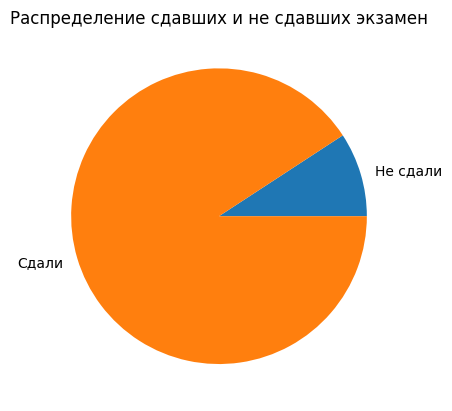

In [61]:
sizes = [len(df[df["Балл"] < df["Минимальный балл"]]), len(df[df["Балл"] >= df["Минимальный балл"]])]
labels = ["Не сдали", "Сдали"]
plt.pie(sizes, labels=labels)
plt.title('Распределение сдавших и не сдавших экзамен')

# Отображение графика
plt.show()

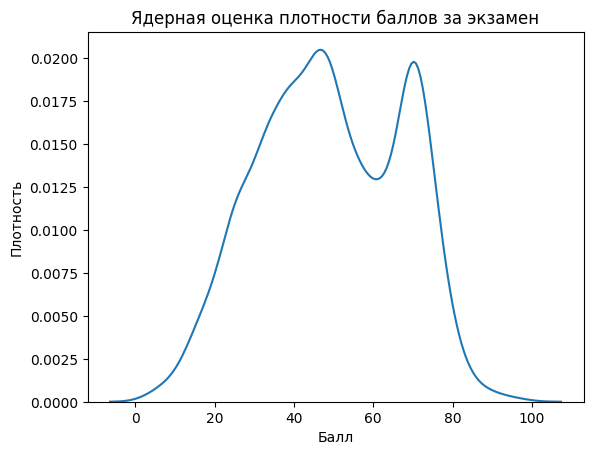

In [63]:
plt.figure()
sns.kdeplot(df['Балл'])
plt.title('Ядерная оценка плотности баллов за экзамен')
plt.xlabel('Балл')
plt.ylabel('Плотность')
plt.show()

In [90]:
def grade(score):
    if score < 27:
        return "Неудовлетворительно (2)"
    elif score < 47:
        return "Удовлетворительно (3)"
    elif score < 65:
        return "Хорошо (4)"
    else:
        return "Отлично (5)"

df["Оценка"] = df["Балл"].apply(grade)

# --- Подсчёт ---
order = ["Отлично (5)", "Хорошо (4)", "Удовлетворительно (3)", "Неудовлетворительно (2)"]
counts = df["Оценка"].value_counts().reindex(order)
pct = (counts / len(df) * 100).round(2)

result = pd.DataFrame({"Количество": counts, "Процент, %": pct})
print(result)
print(f"\nВсего учащихся: {len(df)}")



                         Количество  Процент, %
Оценка                                         
Отлично (5)                     603       25.58
Хорошо (4)                      623       26.43
Удовлетворительно (3)           914       38.78
Неудовлетворительно (2)         217        9.21

Всего учащихся: 2357


In [99]:
m = len(df[df["Пол"] == "М"])
print(f"Мальчиков: {m / len(df) * 100}% \n Девочек: {(len(df)-m)/len(df)*100}%")

Мальчиков: 47.136190072125586% 
 Девочек: 52.863809927874414%


In [ ]:
df["№ школы"].nunique()

17

In [106]:
df[df["Балл"]==96]

,№,№ школы,Класс,Пол,Номер варианта,Задания с кратким ответом,Задания с развёрнутым ответом,Устная часть,Первичный балл,Балл,Минимальный балл,Оценка
2353,2354.0,136.0,11,М,341.0,++++++++++++,2(2)1(2)2(2)1(3)3(3)4(4)2(4),NaN,27.0,96.0,27.0,Отлично (5)
2354,2355.0,136.0,11,М,343.0,++++++++++++,2(2)2(2)2(2)0(3)3(3)4(4)2(4),NaN,27.0,96.0,27.0,Отлично (5)
2355,2356.0,136.0,11,Ж,337.0,++++++++++++,2(2)2(2)2(2)0(3)3(3)4(4)2(4),NaN,27.0,96.0,27.0,Отлично (5)


# part 2

In [ ]:
table = np.zeros((9,9), int)
for i in range(1,11):
    table[i-2] = [x*(i-1) for x in range(1,10)]
table

In [ ]:
def f(n: int, first_number: float, different: float):
    diag = [first_number- (i*different) for i in range(n)]
    A = np.diag(diag)
    return A
f(10, 5, 0.5)

In [ ]:
A = np.array(np.arange(1, 26)).reshape(5,5)
A1 = A[0:5:2, [0,2, 4]]
A2 = A[1:5:2, [1,3]]
A1 = A1.flatten()
A2 = A2.flatten()
Af = np.array([*A1, *A2])
Af

In [ ]:
N = 5 
A = np.ones((N,N))
A[1:4, 1:4] = 0
A

In [ ]:
A = np.zeros([5,5])
A[0:5:2, 0:5:2] = 5
A[2:5:2, 2:5:2] = 5
A

In [ ]:
B = np.zeros([5,5])
Z = np.triu_indices(B, k=0)